In [1]:
import csv
import json
import re
import sys
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from helpers.real_programs import get_real_programs
from helpers.dataset_generation import get_dataset, get_var_names
from helpers.gmm_distance import gmm_w2_distance
from refinestat_degas.text_utils import fix_uniform_trailing_literal

sys.path.insert(0, "../DeGAS/src")
from optimization import compile2SOGA_text, produce_cfg_text, smooth_cfg, start_SOGA
from PROGRAMS.likelihood import compute_likelihood

torch.set_default_dtype(torch.float64)

#set random seed for reproducibility
torch.manual_seed(0)

/home/rdoz/miniconda3/envs/myenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
program = 'hurricane' # Options: "if", "mog1", "burglary", "csi", "easytugwar"
data_size = 50000
code = get_real_programs(program)

var_names = get_var_names(program)
data = get_dataset(program, data_size)

loss = lambda output_dist: -compute_likelihood(output_dist, var_names, data)

print(code)


        preplevel = gm([0.5, 0.2, 0.3], [0, 1, 2], [0, 0, 0]);
        if preplevel == 0 {
            damage = gm([0.2, 0.8], [0, 1], [0, 0]);
        } else {
            if preplevel == 1 {
                damage = gm([0.2, 0.8], [0, 1], [0, 0]);
            } else {
                damage = gm([0.8, 0.2], [0, 1], [0, 0]);
            } end if;
        } end if;


In [3]:
results_root = Path("../results") / program
if not results_root.exists():
    raise FileNotFoundError(f"Results folder not found: {results_root}")

export_dir = results_root / "export"
export_dir.mkdir(parents=True, exist_ok=True)
print(f"Exporting table + plots to: {export_dir.resolve()}")

Exporting table + plots to: /home/rdoz/PhD/LLM-guided_PP_synthesis/results/hurricane/export


## Real program

In [4]:
compiled_real_program = compile2SOGA_text(code)
cfg_real_program = produce_cfg_text(compiled_real_program)
smooth_cfg(cfg_real_program)
output_dist_real_program = start_SOGA(cfg_real_program)
print(f"Real program NLL: {loss(output_dist_real_program):.4f}")

Real program NLL: -10.4549


In [5]:
def sample_ordered(output_dist, n, var_names):
    idx = [output_dist.var_list.index(v) for v in var_names]
    return output_dist.gm.sample(n)[:, idx]


def samples_to_csv(samples, path, var1=0, var2=1):
    pd.DataFrame({
        var_names[var1]: samples[:, var1].detach().numpy(),
        var_names[var2]: samples[:, var2].detach().numpy(),
    }).to_csv(path, index=False)


def scatter_vs_real(output_dist, name, var1=0, var2=1, n=50):
    """Scatter `output_dist`'s samples against the real program's, exporting a PNG plus two
    CSVs to export_dir: the real program's samples (written once, shared across methods) and
    this method's own samples (no method/source column -- one file per distribution)."""
    samples = sample_ordered(output_dist, n, var_names)
    slug = re.sub(r"[^A-Za-z0-9_.-]+", "_", name)

    samples_to_csv(samples, export_dir / f"scatter_{slug}.csv", var1, var2)

    plt.figure(figsize=(6, 5))
    plt.scatter(real_samples[:, var1], real_samples[:, var2], alpha=0.5, label="Real program", color="blue")
    plt.scatter(samples[:, var1], samples[:, var2], alpha=0.5, label=name, color="orange")
    plt.xlabel(var_names[var1])
    plt.ylabel(var_names[var2])
    plt.title(f"{name} vs real program ({program})")
    plt.legend()
    plt.savefig(export_dir / f"scatter_{slug}.png", dpi=150, bbox_inches="tight")
    plt.show()


var1, var2 = 0, 1
real_samples = sample_ordered(output_dist_real_program, 50, var_names)
samples_to_csv(real_samples, export_dir / "scatter_real_program.csv", var1, var2)

## Simple benchmark

A naive DeGAS program where every variable of the dataset is declared independently as a single Gaussian with the empirical mean and standard deviation of that variable's column in the data (no conditional structure at all).

In [6]:
data_arr = np.array(data, dtype=float)
benchmark_lines = []
for i, name in enumerate(var_names):
    mean = data_arr[:, i].mean()
    std = data_arr[:, i].std()
    benchmark_lines.append(f"{name} = gm([1.00], [{mean:.6f}], [{std:.6f}]);")
benchmark_program = "\n".join(benchmark_lines)
print(benchmark_program)

compiled_benchmark = compile2SOGA_text(benchmark_program)
cfg_benchmark = produce_cfg_text(compiled_benchmark)
smooth_cfg(cfg_benchmark)
output_dist_benchmark = start_SOGA(cfg_benchmark)
print(f"Benchmark NLL: {loss(output_dist_benchmark):.4f}")

preplevel = gm([1.00], [0.798720], [0.872219]);
damage = gm([1.00], [0.623160], [0.484594]);
Benchmark NLL: 1.9767


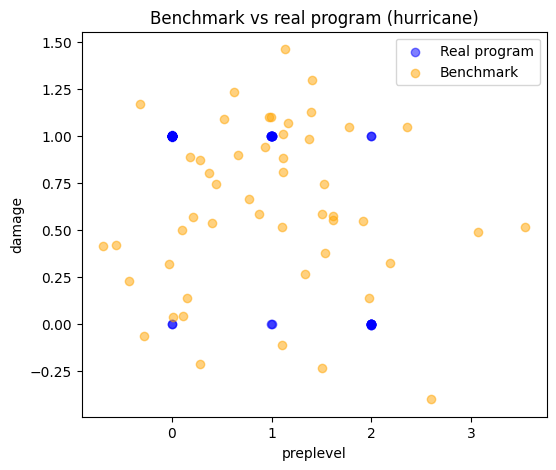

In [7]:
scatter_vs_real(output_dist_benchmark, "Benchmark")

## Loading runs from `results/<program>`

ALPS runs live directly under `results_root` (one subfolder per run). The other methods each live in their own subfolder: `grammar_mcmc/`, `refinestat/`, `refinestat_mcmc/`. Every run folder has a `best_fitness.csv` (columns `iteration,best_loss`) and a `final_candidates.json`.

In [8]:
METHOD_SUBDIRS = {
    "ALPS": None,                 # runs live directly under results_root
    "grammar_mcmc": "grammar_mcmc",
    "refinestat": "refinestat",
    "refinestat_mcmc": "refinestat_mcmc",
}
KNOWN_METHOD_DIRNAMES = {v for v in METHOD_SUBDIRS.values() if v is not None}


def run_dirs_for_method(method):
    subdir = METHOD_SUBDIRS[method]
    base = results_root / subdir if subdir else results_root
    if not base.exists():
        return []
    dirs = []
    for sub in base.iterdir():
        if not sub.is_dir():
            continue
        if subdir is None and sub.name in KNOWN_METHOD_DIRNAMES:
            continue  # skip other methods' subfolders when scanning ALPS
        if (sub / "best_fitness.csv").exists():
            dirs.append(sub)
    return sorted(dirs)


def load_best_fitness(run_dir):
    with open(run_dir / "best_fitness.csv", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        rows = [
            (int(row["iteration"]), float(row["best_loss"]))
            for row in reader
            if row.get("best_loss") not in (None, "")
        ]
    return rows


def load_elapsed_seconds(run_dir):
    """Each method's driver writes hyperparams.json with an 'elapsed_seconds' wall-clock
    total for that run (see llm_synthesis.py, refinestat_degas/main.py, grammar_mcmc/main.py)."""
    hyperparams_path = run_dir / "hyperparams.json"
    if not hyperparams_path.exists():
        return None
    with open(hyperparams_path, encoding="utf-8") as f:
        hyperparams = json.load(f)
    return hyperparams.get("elapsed_seconds")


def avg_elapsed_seconds(method):
    times = [t for run_dir in run_dirs_for_method(method) if (t := load_elapsed_seconds(run_dir)) is not None]
    return float(np.mean(times)) if times else np.nan


def best_run_for_method(method):
    """Across all runs of `method`, return the run dir that reaches the lowest best_loss, and that value."""
    best_dir, best_loss = None, float("inf")
    for run_dir in run_dirs_for_method(method):
        rows = load_best_fitness(run_dir)
        if not rows:
            continue
        run_loss = min(l for _, l in rows)
        if run_loss < best_loss:
            best_loss = run_loss
            best_dir = run_dir
    return best_dir, best_loss


def get_candidate_params(candidate):
    if "posterior_mean_params" in candidate:
        return candidate["posterior_mean_params"]
    return candidate.get("optimized_params", {})


def parse_tensor_str(value):
    """str(torch.tensor(...)) renders as 'tensor(X, requires_grad=True)' when the tensor
    requires grad, but just 'tensor(X)' -- no comma -- when it doesn't (e.g. skip_gradient
    ablation runs, or any already-detached value). Splitting on ',' then leaves a trailing
    ')' in the parsed string for the no-comma case (e.g. '-1.1340)'), which float() rejects.
    A regex anchored on the first '(' up to the first ',' or ')' handles both forms."""
    m = re.search(r"tensor\(([^,)]+)", value)
    if not m:
        raise ValueError(f"could not parse tensor repr: {value!r}")
    return float(m.group(1))


def substitute_params(rewritten, params):
    for name, value in params.items():
        if isinstance(value, str) and value.startswith("tensor"):
            value = parse_tensor_str(value)
        # Python's str()/repr() renders very small/large floats in scientific notation
        # (e.g. "2.0626e-12"), but DeGAS's grammar (SOGA.g4: NUM : '-'? DIGIT+ ('.' DIGIT*)?)
        # has no exponent support -- substituting that text silently corrupts the compile
        # (ANTLR error-recovers into a garbled distribution rather than raising). Fixed-
        # decimal formatting avoids that regardless of magnitude.
        formatted = f"{float(value):.20f}"
        pattern = rf"_{re.escape(name)}(?![A-Za-z0-9_])"
        rewritten = re.sub(pattern, formatted, rewritten)
    return rewritten


def best_candidate_for_method(method):
    """Best run dir's best (first) candidate, with its params substituted in. Returns (run_dir, rewritten) or (None, None)."""
    run_dir, run_loss = best_run_for_method(method)
    if run_dir is None:
        print(f"No runs found for method '{method}'.")
        return None, None
    candidates_path = run_dir / "final_candidates.json"
    if not candidates_path.exists():
        print(f"{run_dir} has no final_candidates.json.")
        return None, None
    with open(candidates_path, encoding="utf-8") as f:
        candidates = json.load(f)
    if not candidates:
        print(f"{run_dir} has no candidates in final_candidates.json.")
        return None, None
    candidate = candidates[0]
    rewritten = substitute_params(candidate["rewritten"], get_candidate_params(candidate))
    print(f"Best {method} run: {run_dir} (best_loss={run_loss:.4f})")
    return run_dir, rewritten

## ALPS loss evolution across runs

Scatter of every (iteration, best_loss) point from every ALPS run, with the per-iteration median and interquartile range overlaid.

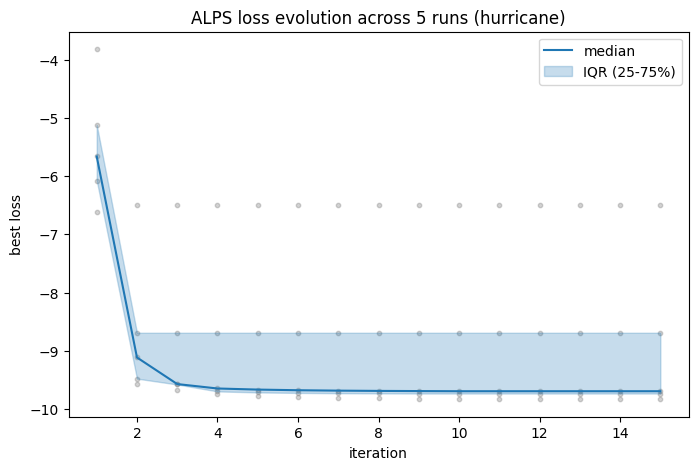

In [9]:
alps_run_dirs = run_dirs_for_method("ALPS")
if not alps_run_dirs:
    print("No ALPS runs found.")
else:
    curves = {}
    for run_dir in alps_run_dirs:
        rows = load_best_fitness(run_dir)
        if rows:
            iters, losses = zip(*rows)
            curves[run_dir.name] = pd.Series(losses, index=iters)
    curves_df = pd.DataFrame(curves)
    median = curves_df.median(axis=1)
    q25 = curves_df.quantile(0.25, axis=1)
    q75 = curves_df.quantile(0.75, axis=1)

    alps_evolution_csv = pd.DataFrame({"median": median, "q25": q25, "q75": q75})
    alps_evolution_csv.index.name = "iteration"
    alps_evolution_csv.to_csv(export_dir / "alps_loss_evolution.csv")

    plt.figure(figsize=(8, 5))
    for col in curves_df.columns:
        s = curves_df[col].dropna()
        plt.scatter(s.index, s.values, s=10, alpha=0.35, color="gray")
    plt.plot(median.index, median.values, color="C0", label="median")
    plt.fill_between(median.index, q25.values, q75.values, alpha=0.25, color="C0", label="IQR (25-75%)")
    plt.xlabel("iteration")
    plt.ylabel("best loss")
    plt.title(f"ALPS loss evolution across {len(alps_run_dirs)} runs ({program})")
    plt.legend()
    plt.savefig(export_dir / "alps_loss_evolution.png", dpi=150, bbox_inches="tight")
    plt.show()

## Final loss by method

Box plot (median + interquartile range) of the final-iteration `best_loss` for every run of every method.

/home/rdoz/miniconda3/envs/myenv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/home/rdoz/miniconda3/envs/myenv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4674: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,


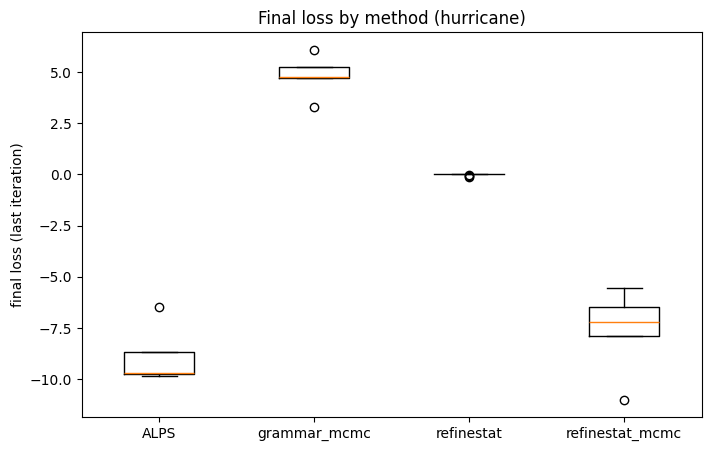

In [10]:
final_losses = {}
for method in METHOD_SUBDIRS:
    values = [rows[-1][1] for run_dir in run_dirs_for_method(method) if (rows := load_best_fitness(run_dir))]
    if values:
        final_losses[method] = values
    else:
        print(f"No runs with a final loss found for method '{method}'.")

final_losses_csv = pd.DataFrame({method: pd.Series(values) for method, values in final_losses.items()})
final_losses_csv.to_csv(export_dir / "final_loss_boxplot.csv", index=False)

plt.figure(figsize=(8, 5))
plt.boxplot(list(final_losses.values()), tick_labels=list(final_losses.keys()))
plt.ylabel("final loss (last iteration)")
plt.title(f"Final loss by method ({program})")
plt.savefig(export_dir / "final_loss_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

## Best candidate per method: sample scatter vs the real program

Best ALPS run: ../results/hurricane/20260826_112916 (best_loss=-9.8323)


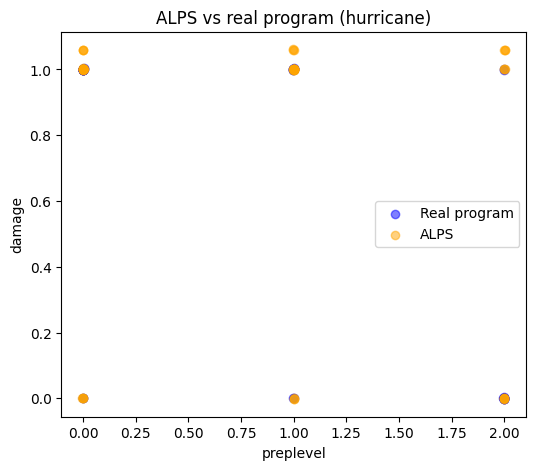

Best grammar_mcmc run: ../results/hurricane/grammar_mcmc/20260821_075509_seed5 (best_loss=3.2884)


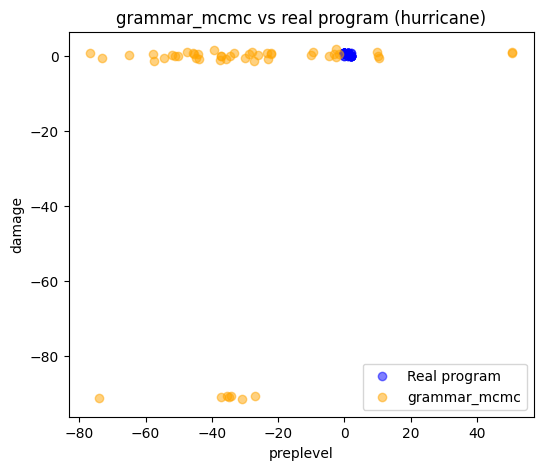

Best refinestat run: ../results/hurricane/refinestat/20260830_105508_seed2 (best_loss=-0.1215)


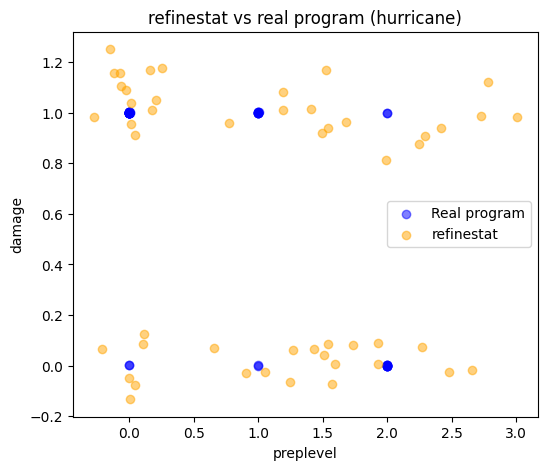

Best refinestat_mcmc run: ../results/hurricane/refinestat_mcmc/20260821_171458_seed2 (best_loss=-11.0062)


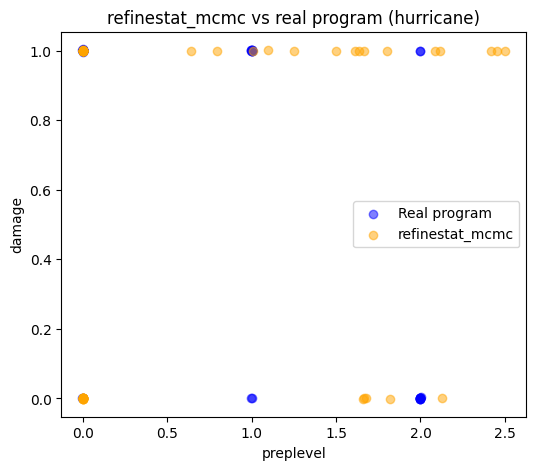

In [11]:
method_output_dists = {}
for method in METHOD_SUBDIRS:
    run_dir, rewritten = best_candidate_for_method(method)
    if rewritten is None:
        continue
    try:
        compiled = compile2SOGA_text(fix_uniform_trailing_literal(rewritten))
        cfg = produce_cfg_text(compiled)
        smooth_cfg(cfg)
        output_dist = start_SOGA(cfg)
    except Exception as e:
        print(f"Could not evaluate best candidate for '{method}': {e}")
        continue
    method_output_dists[method] = output_dist
    scatter_vs_real(output_dist, method)

## External baseline: Evolutionary PP Synthesis (grammatical evolution, no sketch)

Pulls the best individual (highest `Fitness on 5000 data`, i.e. lowest NLL) across all runs from
[r-doz/Evolutionary-PP-Synthesis](https://github.com/r-doz/Evolutionary-PP-Synthesis)'s `results/<folder>`
for this `program` (see `EVOLUTIONARY_RESULTS_DIR` below), translates its phenotype from that repo's
per-component `gm([w,mu,sigma], ...)` / relative-width `uniform([a,b],c)` syntax into DeGAS's
`gm([w...],[mu...],[sigma...])` / absolute-bounds `uniform([a,b],c)` syntax -- mirroring that repo's own
`src/fitness/SOGATorch_fitness.py::convert_and_normalize_gm_structure` / `convert_uniform_structure`
(weights are renormalized to sum to 1, since that repo's raw GP-evolved weights aren't a simplex) -- and
compiles it through our own DeGAS pipeline so its NLL and GW2 distance are computed exactly like every
other method above, rather than trusting a number computed by a different pipeline.

In [12]:
import urllib.request

EVOLUTIONARY_REPO = "r-doz/Evolutionary-PP-Synthesis"
EVOLUTIONARY_RESULTS_DIR = {
    "if": "if_sketch0_30",
    "mog1": "mog1_sketch0_30",
    "easytugwar": "easytugwar_sketch0_30",
    "csi": "csi_nosketch",
    "biasedtugwar": "biasedtugwar_nosketch_30",
    "mixedcondition": "mixedcondition_sketch0_30",
    "multiplebranches": "multiplebranches_sketch0_30",
    "hurricane": "hurricane_nosketch",
    "eyecolor": "eyecolor_nosketch",
    # add other programs here once their evolutionary-baseline result folder is known
}


def fetch_text(url):
    with urllib.request.urlopen(url, timeout=20) as resp:
        return resp.read().decode("utf-8")


def list_github_subdirs(repo, path, ref="master"):
    api_url = f"https://api.github.com/repos/{repo}/contents/{path}?ref={ref}"
    entries = json.loads(fetch_text(api_url))
    return [e["name"] for e in entries if e["type"] == "dir"]


def parse_best_txt(text):
    """Parse a PonyGE2-style best.txt as saved by that repo's save_best_ind_to_file."""
    result = {}
    m = re.search(r"Phenotype:\n(.*?)\n\nGenotype:", text, re.S)
    if m:
        result["phenotype"] = m.group(1).strip()
    m = re.search(r"Fitness on 5000 data:\n([^\n]+)", text)
    if m:
        result["fitness_test"] = float(m.group(1))
    m = re.search(r"\nFitness:\n([^\n]+)", text)
    if m:
        result["fitness_train"] = float(m.group(1))
    return result


def convert_evolutionary_gm(text):
    """gm([w1,mu1,s1], [w2,mu2,s2], ...) -> DeGAS's gm([w...],[mu...],[s...]), weights
    renormalized to sum to 1 (mirrors that repo's convert_and_normalize_gm_structure)."""
    pattern = r'gm\(\s*(\[[^\]]+\](?:,\s*\[[^\]]+\])*)\s*\)'

    def repl(m):
        elements = re.findall(r'\[\s*([0-9.eE+-]+)\s*,\s*([0-9.eE+-]+)\s*,\s*([0-9.eE+-]+)\s*\]', m.group(1))
        pis = [float(e[0]) for e in elements]
        mus = [e[1] for e in elements]
        sigmas = [e[2] for e in elements]
        pi_sum = sum(pis) or 1.0
        norm_pis = ", ".join(f"{p / pi_sum:.6f}" for p in pis)
        return f'gm([{norm_pis}], [{", ".join(mus)}], [{", ".join(sigmas)}])'

    return re.sub(pattern, repl, text)


def convert_evolutionary_uniform(text):
    """uniform([a,b], c) -> DeGAS's uniform([a, a+b], c): their second bracket value is a
    width, ours an absolute upper bound (mirrors that repo's convert_uniform_structure)."""
    pattern = r'uniform\(\s*\[\s*([0-9.eE+-]+)\s*,\s*([0-9.eE+-]+)\s*\]\s*,\s*([0-9.eE+-]+)\s*\)'

    def repl(m):
        a, b, c = float(m.group(1)), float(m.group(2)), m.group(3)
        return f'uniform([{a:.6f}, {a + b:.6f}], {c})'

    return re.sub(pattern, repl, text)


def translate_evolutionary_phenotype(phenotype):
    p = convert_evolutionary_gm(phenotype)
    p = convert_evolutionary_uniform(p)
    p = re.sub(r";;+", ";", p)  # stray double-semicolons seen in some phenotypes
    return p


evolutionary_output_dist = None
evolutionary_avg_time = np.nan

evo_folder = EVOLUTIONARY_RESULTS_DIR.get(program)
if evo_folder is None:
    print(f"No Evolutionary-PP-Synthesis result folder known for program '{program}'.")
else:
    evo_results_path = f"results/{evo_folder}"
    try:
        run_names = list_github_subdirs(EVOLUTIONARY_REPO, evo_results_path)
    except Exception as e:
        print(f"Could not list {EVOLUTIONARY_REPO}/{evo_results_path}: {e}")
        run_names = []

    evo_runs = []
    for name in run_names:
        try:
            text = fetch_text(
                f"https://raw.githubusercontent.com/{EVOLUTIONARY_REPO}/master/{evo_results_path}/{name}/best.txt"
            )
            parsed = parse_best_txt(text)
            if "phenotype" in parsed and "fitness_test" in parsed:
                parsed["run"] = name
                evo_runs.append(parsed)
        except Exception as e:
            print(f"Could not fetch/parse {name}/best.txt: {e}")

    if not evo_runs:
        print(f"No usable runs found under {EVOLUTIONARY_REPO}/{evo_results_path}.")
    else:
        best_evo_run = max(evo_runs, key=lambda r: r["fitness_test"])
        print(
            f"Best Evolutionary-PP-Synthesis run: {best_evo_run['run']} "
            f"(Fitness on 5000 data = {best_evo_run['fitness_test']:.4f}, "
            f"i.e. NLL = {-best_evo_run['fitness_test']:.4f}, over {len(evo_runs)}/{len(run_names)} runs)"
        )
        translated_phenotype = translate_evolutionary_phenotype(best_evo_run["phenotype"])
        
        #if the program is eyecolor replace "haitlength" with "haitlenght   "
        if program == "eyecolor":
            translated_phenotype = translated_phenotype.replace("hairlength", "hairlenght")
            print(translated_phenotype)
        try:
            evo_compiled = compile2SOGA_text(fix_uniform_trailing_literal(translated_phenotype))
            evo_cfg = produce_cfg_text(evo_compiled)
            smooth_cfg(evo_cfg)
            evolutionary_output_dist = start_SOGA(evo_cfg)
        except Exception as e:
            print(f"Could not compile translated evolutionary phenotype: {e}")

    try:
        total_time_last_row = fetch_text(
            f"https://raw.githubusercontent.com/{EVOLUTIONARY_REPO}/master/{evo_results_path}/total_time.csv"
        ).strip().splitlines()[-1]
        evolutionary_avg_time = float(np.mean([float(x) for x in total_time_last_row.split(",")]))
    except Exception as e:
        print(f"Could not compute average time from total_time.csv: {e}")

Best Evolutionary-PP-Synthesis run: DESKTOP-3B7BIDK_25_1_28_105522_790235_6992_1 (Fitness on 5000 data = -1.5809, i.e. NLL = 1.5809, over 30/30 runs)


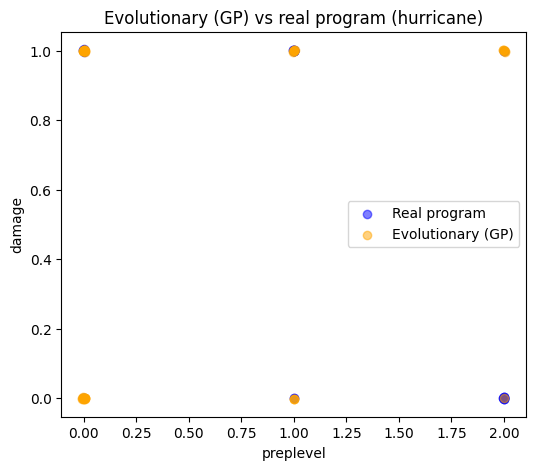

In [13]:
if evolutionary_output_dist is not None:
    scatter_vs_real(evolutionary_output_dist, "Evolutionary (GP)")

## Summary table: NLL and GW2 distance to the real program

GW2 is the Gaussian-mixture Wasserstein distance from `helpers.gmm_distance` (see `evaluate_program.ipynb`), computed between each output distribution and the real program's, restricted and reordered to `var_names` so every distribution is compared on the same dimensions.

In [14]:
def restrict_to_var_names(output_dist, var_names):
    idx = torch.tensor([output_dist.var_list.index(v) for v in var_names])
    mu = output_dist.gm.mu[:, idx]
    sigma = output_dist.gm.sigma[:, idx][:, :, idx]
    return SimpleNamespace(pi=output_dist.gm.pi, mu=mu, sigma=sigma)


def gw2_to_real(output_dist):
    try:
        real_gm = restrict_to_var_names(output_dist_real_program, var_names)
        other_gm = restrict_to_var_names(output_dist, var_names)
        return gmm_w2_distance(real_gm, other_gm)
    except Exception as e:
        print(f"Could not compute GW2 distance: {e}")
        return np.nan


rows = [
    ["Real program", float(loss(output_dist_real_program)), 0.0, np.nan],
    ["Benchmark", float(loss(output_dist_benchmark)), gw2_to_real(output_dist_benchmark), np.nan],
]
for method, output_dist in method_output_dists.items():
    rows.append([method, float(loss(output_dist)), gw2_to_real(output_dist), avg_elapsed_seconds(method)])
if evolutionary_output_dist is not None:
    rows.append([
        "Evolutionary (GP)",
        float(loss(evolutionary_output_dist)),
        gw2_to_real(evolutionary_output_dist),
        evolutionary_avg_time,
    ])

results_table = pd.DataFrame(rows, columns=["Method", "NLL", "GW2 distance to real program", "Avg time (s)"])
results_table.to_csv(export_dir / "results_table.csv", index=False)
print(f"Saved table to: {(export_dir / 'results_table.csv').resolve()}")
results_table

Saved table to: /home/rdoz/PhD/LLM-guided_PP_synthesis/results/hurricane/export/results_table.csv


,Method,NLL,GW2 distance to real program,Avg time (s)
0,Real program,-10.454851,0.000000,NaN
1,Benchmark,1.976719,1.988497,NaN
2,ALPS,-9.817539,0.300703,2166.737079
3,grammar_mcmc,3.285107,1804.535837,56.520161
4,refinestat,-0.098359,0.771688,1914.748621
5,refinestat_mcmc,-7.252883,0.418983,19768.235723
6,Evolutionary (GP),-9.086871,0.242863,1415.616070


In [5]:
program = 'csi' # Options: "if", "mog1", "burglary", "csi", "easytugwar"
data_size = 50000
code = get_real_programs(program)
var_names = get_var_names(program)
data = get_dataset(program, data_size)

loss = lambda output_dist: -compute_likelihood(output_dist, var_names, data)


compiled_real_program = compile2SOGA_text(code)
cfg_real_program = produce_cfg_text(compiled_real_program)
smooth_cfg(cfg_real_program)
output_dist_real_program = start_SOGA(cfg_real_program)
print(f"Real program NLL: {loss(output_dist_real_program):.4f}")


print(code)

Real program NLL: -22.1973

        u = gm([0.3, 0.7], [1, 0], [0, 0]);
        v = gm([0.9, 0.1], [1, 0], [0, 0]);
        w = gm([0.1, 0.9], [1, 0], [0, 0]);

        if u == 1 {
            if w == 1{
                x = gm([0.8, 0.2], [1, 0], [0, 0]);
            } else {
                x = gm([0.2, 0.8], [1, 0], [0, 0]);
            } end if;
        } else {
            if v == 1{
                x = gm([0.8, 0.2], [1, 0], [0, 0]);
            } else {
                x = gm([0.2, 0.8], [1, 0], [0, 0]);
            } end if;
        } end if;
